Dataset Preview
   OrderID CustomerName     Product     Category  Quantity  Price  Discount  \
0     1001         John      Laptop  Electronics         2  55000      0.10   
1     1002        Alice       Phone  Electronics         1  30000      0.05   
2     1003          Bob       Chair    Furniture         4   2500      0.15   
3     1004         Emma       Table    Furniture         2   6000      0.10   
4     1005        David  Headphones  Electronics         3   2000      0.05   

  Region  
0  South  
1  North  
2   East  
3   West  
4  South  

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       10 non-null     int64  
 1   CustomerName  10 non-null     object 
 2   Product       10 non-null     object 
 3   Category      10 non-null     object 
 4   Quantity      10 non-null     int64  
 5   Price         10 non-n

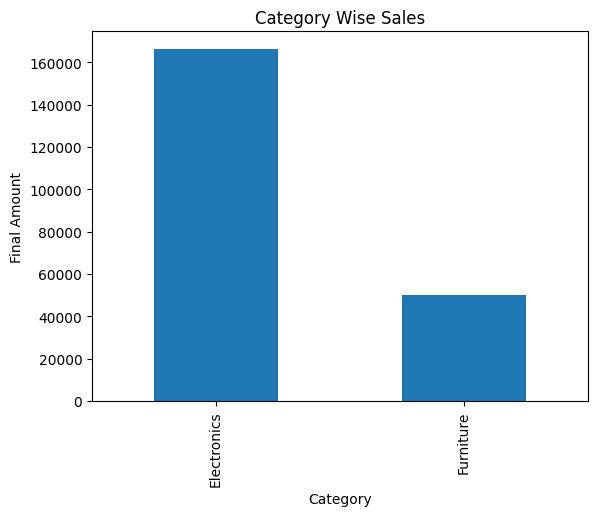


Final Dataset
   OrderID CustomerName     Product     Category  Quantity  Price  Discount  \
0     1001         John      Laptop  Electronics         2  55000      0.10   
1     1002        Alice       Phone  Electronics         1  30000      0.05   
2     1003          Bob       Chair    Furniture         4   2500      0.15   
3     1004         Emma       Table    Furniture         2   6000      0.10   
4     1005        David  Headphones  Electronics         3   2000      0.05   
5     1006       Sophia     Monitor  Electronics         1  12000      0.08   
6     1007      Michael        Sofa    Furniture         1  25000      0.12   
7     1008       Olivia    Keyboard  Electronics         5   1500      0.05   
8     1009        James     Printer  Electronics         2   8000      0.07   
9     1010    Charlotte        Desk    Furniture         1  10000      0.10   

  Region  TotalSales  DiscountAmount  FinalAmount   Profit RegionCode  \
0  South      110000         11000.0      

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Create Dataset
data = {
    "OrderID":[1001,1002,1003,1004,1005,1006,1007,1008,1009,1010],
    "CustomerName":["John","Alice","Bob","Emma","David","Sophia","Michael","Olivia","James","Charlotte"],
    "Product":["Laptop","Phone","Chair","Table","Headphones","Monitor","Sofa","Keyboard","Printer","Desk"],
    "Category":["Electronics","Electronics","Furniture","Furniture","Electronics","Electronics","Furniture","Electronics","Electronics","Furniture"],
    "Quantity":[2,1,4,2,3,1,1,5,2,1],
    "Price":[55000,30000,2500,6000,2000,12000,25000,1500,8000,10000],
    "Discount":[0.10,0.05,0.15,0.10,0.05,0.08,0.12,0.05,0.07,0.10],
    "Region":["South","North","East","West","South","North","East","West","South","North"]
}

df = pd.DataFrame(data)

# Basic Info
print("Dataset Preview")
print(df.head())

print("\nDataset Info")
df.info()

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# Feature Creation
df["TotalSales"] = df["Quantity"] * df["Price"]
df["DiscountAmount"] = df["TotalSales"] * df["Discount"]
df["FinalAmount"] = df["TotalSales"] - df["DiscountAmount"]
df["Profit"] = df["FinalAmount"] * 0.20

# map()
df["RegionCode"] = df["Region"].map({
    "North":"N",
    "South":"S",
    "East":"E",
    "West":"W"
})

# apply()
df["RevenueCategory"] = df["FinalAmount"].apply(
    lambda x: "High" if x > 50000 else ("Medium" if x > 10000 else "Low")
)

# No applymap (removed to avoid warning)

# Analysis
print("\nCategory Wise Sales")
print(df.groupby("Category")["FinalAmount"].sum())

print("\nRegion Wise Sales")
print(df.groupby("Region")["FinalAmount"].sum())

print("\nRevenue Category Count")
print(df["RevenueCategory"].value_counts())

print("\nTop Products by Sales")
print(df.groupby("Product")["FinalAmount"].sum().sort_values(ascending=False))

# Visualization
df.groupby("Category")["FinalAmount"].sum().plot(kind="bar")
plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Final Amount")
plt.show()

# Final Dataset
print("\nFinal Dataset")
print(df.head(10))